In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import matplotlib.cm as cm
from matplotlib.patches import Patch

In [3]:
cwd = os.getcwd()
cwd

'/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models'

In [4]:
def get_data(file):
    x_data = []
    y_data = []
    
    with open(file, 'r') as f:
        for line in f:
            if not line.startswith(('@', '#')):  # Skip header lines
                parts = line.strip().split()
                if len(parts) >= 2:  # Ensure there are at least two columns of data
                    try:
                        x_data.append(float(parts[0]))
                        y_data.append(float(parts[1]))
                    except ValueError:
                        # Handle cases where data might not be purely numerical
                        continue
    return np.array(x_data), np.array(y_data)

In [5]:
def summary_stats(data):  
    
    data_mean = np.mean(data)
    data_std = np.std(data)
    data_min = np.min(data)
    data_max = np.max(data)
    
    return data_mean, data_std, data_min, data_max

Binder sequences loaded:    37
Nonbinder sequences loaded: 90

Residues in common: 182
         Binder mean (A)  Binder SD (A)  Nonbinder mean (A)  Nonbinder SD (A)  Diff (B - NB, A)  % diff (vs NB)
Residue                                                                                                        
1                 5.6089         1.8470              5.7183            1.7350           -0.1094           -1.91
2                 3.7337         1.4083              3.8433            1.3100           -0.1096           -2.85
3                 2.8694         0.8736              2.9693            0.7657           -0.0999           -3.36
4                 2.7085         0.5590              2.6743            0.4399            0.0342            1.28
5                 1.4871         0.3813              1.5197            0.3839           -0.0326           -2.14
6                 1.5144         0.4021              1.4783            0.3534            0.0361            2.44
7                

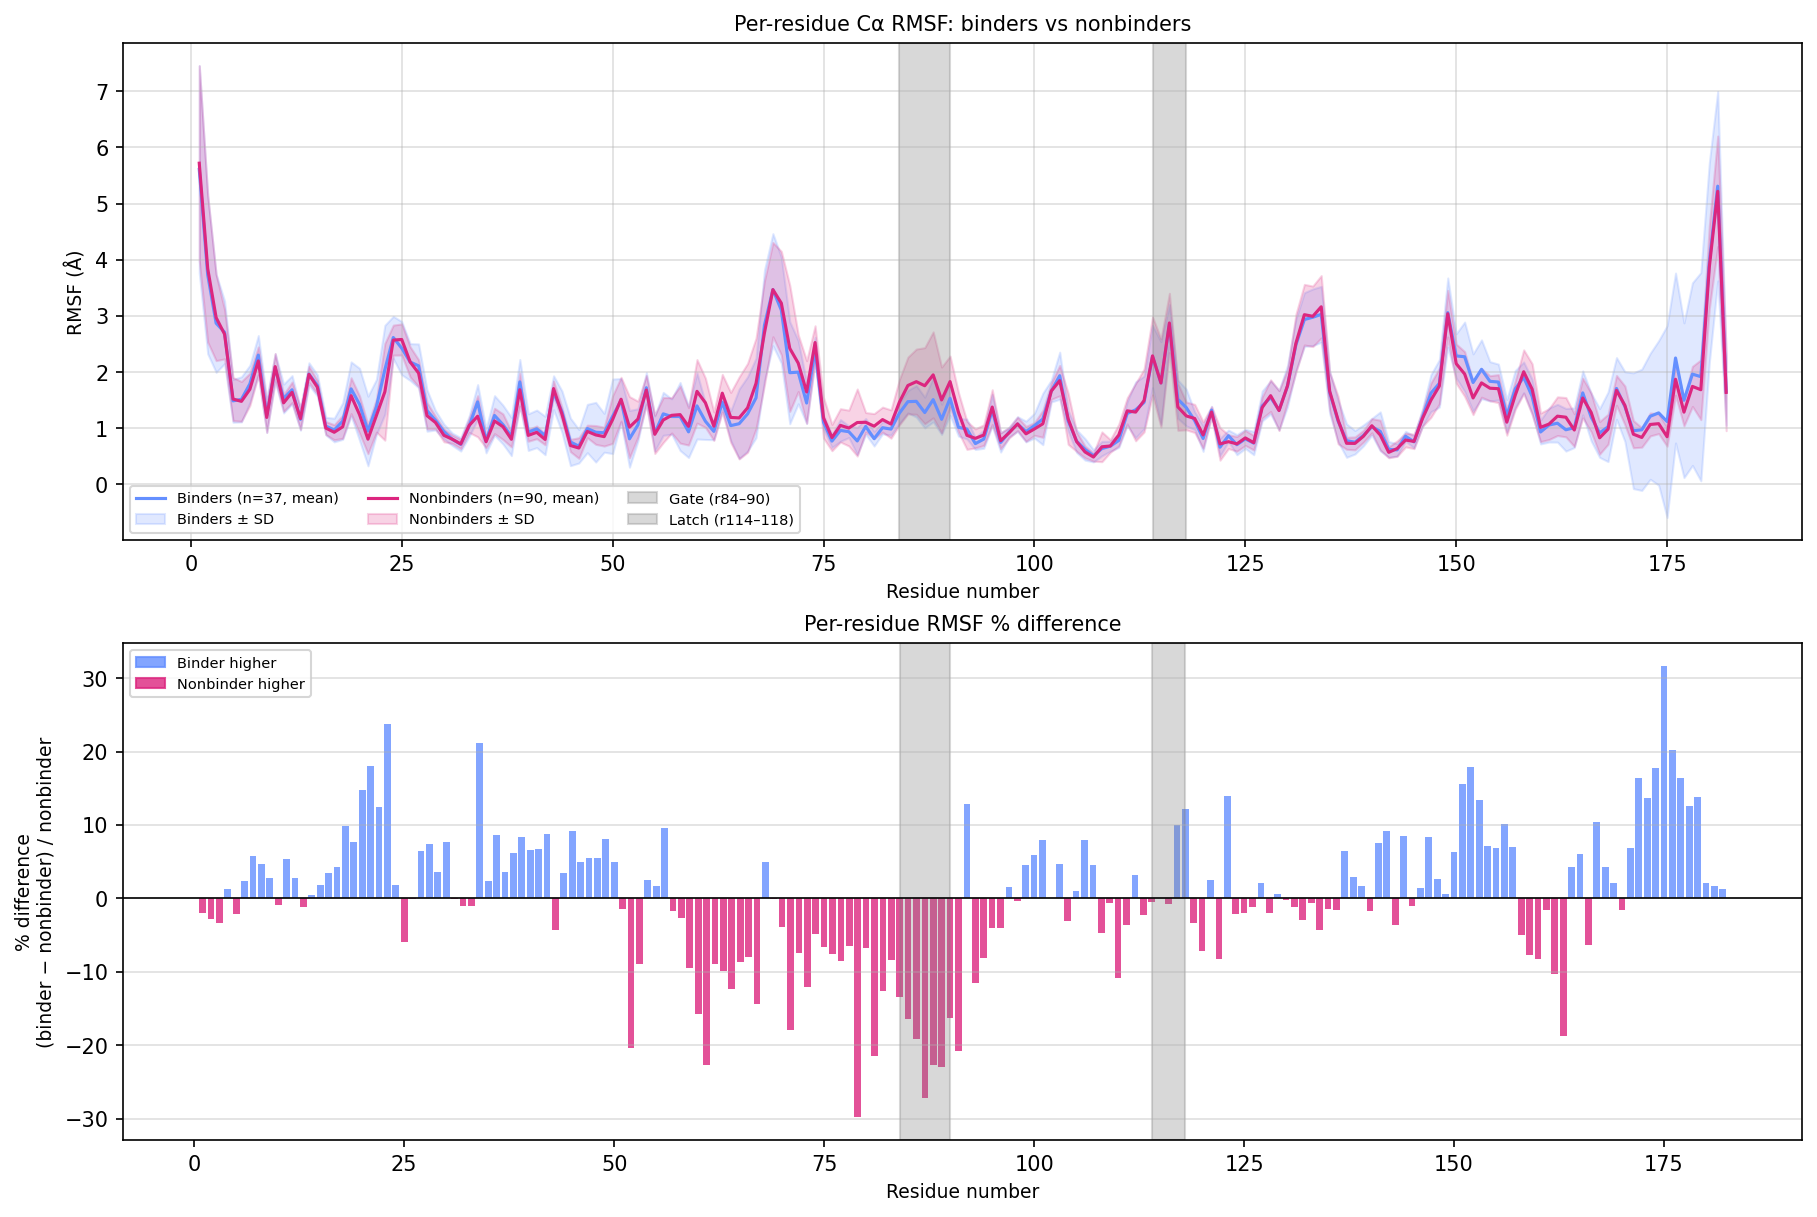

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Plot average per-residue RMSF for binders vs nonbinders
# Combines legacy seqID and new pair_XXXX naming conventions
# Binders: legacy binders + pair binders
# Nonbinders: legacy nb + pair nb + low_pkt + fail_gate
# ------------------------------------------------------------
base   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
runrel = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"

TYPE_SUBDIR = {
    "binder":    "binders",
    "nb":        "nonbinders",
    "low_pkt":   "neg_low_pkt",
    "fail_gate": "neg_fail_gate",
}

# Legacy seqID-style
legacy_binder_ids = ["seq16", "seq14", "seq10", "seq17", "seq39", "seq42"]
legacy_nb_ids     = ["seq1",  "seq2",  "seq3",  "seq4",  "seq5",  "seq6",  "seq7"]

# New pair_XXXX-style
pair_binder_ids      = ["3069", "3070", "3074", "3092", "3098", 
                        "3059", "3062", "3063", "3066", "3067", 
                        "3068", "3071", "3072", "3073", "3075",
                        "3076", "3077", "3078", "3079", "3080", 
                        "3085", "3086", "3087", "3088", "3091", 
                        "3099", "3100", "3101", "3103", "3104", "3108"]
pair_nb_ids          = ["0052", "0091", "0246", "0269", "0272",
                        "0276", "0288", "0351", "0502", "0506",
                        "0647", "0777", "0827", "1824", "1939",
                        "0822", "0865", "0867", "1860", 
                        "1965",
                        "0341", "0450", "0549", "0567", "0584",
                        "0602", "0684", "0736", "0748", "0765",
                        "0811", "0868", "0876", "0878", "0883",
                        "0891", "0908", "0932", "0940", "0974", 
                        "0977", "1011", "1023", "1102", "1313", 
                        "1397", "1654", "1656", "1658", "1671",
                        "1679", "1709", "1710", "1737", "1758",
                        "1784", "1785", "1792", "1835", "1847",
                        "1914", "1922", "1938", "1961"]
pair_low_pkt_ids     = ["0008", "0393", "0482", "1331", "1931",
                        "0065", "0947", "0948", "1413"]
pair_fail_gate_ids   = ["0715", "1094", "1682", "1739", "1941",
                        "0014", "0263", "0540", "0997", "1745"]

# Each entry: (folder_name, seq_type)
binder_list = (
    [(f"{sid}_binder", "binder") for sid in legacy_binder_ids] +
    [(f"pair_{i}_binder",    "binder")    for i in pair_binder_ids]
)

nonbinder_list = (
    [(f"{sid}_nb",           "nb")        for sid in legacy_nb_ids]       +
    [(f"pair_{i}_nb",        "nb")        for i in pair_nb_ids]           +
    [(f"pair_{i}_low_pkt",   "low_pkt")   for i in pair_low_pkt_ids]      +
    [(f"pair_{i}_fail_gate", "fail_gate") for i in pair_fail_gate_ids]
)

NM_TO_ANG = 10.0

# -------------------------------------------------------------------
# Load per-residue RMSF for a list of (folder_name, seq_type) tuples
# Returns a dict: {residue_id: [rmsf_seq1, rmsf_seq2, ...]} in Å
# -------------------------------------------------------------------
def load_rmsf_group(seq_list):
    group = {}
    for folder_name, seq_type in seq_list:
        filepath = os.path.join(base, TYPE_SUBDIR[seq_type], folder_name,
                                runrel, "rmsf_PL.xvg")
        if not os.path.exists(filepath):
            print(f"WARNING: not found — {filepath}")
            continue
        _, rmsf_nm = get_data(filepath)
        # get_data returns arrays indexed from 0; we need residue IDs from col0
        x_data, y_data = get_data(filepath)
        for resid, rmsf in zip(x_data.astype(int), y_data):
            group.setdefault(resid, []).append(rmsf * NM_TO_ANG)
    return group

binder_data    = load_rmsf_group(binder_list)
nonbinder_data = load_rmsf_group(nonbinder_list)

print(f"Binder sequences loaded:    {len(binder_list)}")
print(f"Nonbinder sequences loaded: {len(nonbinder_list)}")

# -------------------------------------------------------------------
# Compute per-residue mean and SD for residues present in both groups
# -------------------------------------------------------------------
common_residues = sorted(set(binder_data.keys()) & set(nonbinder_data.keys()))

rows = []
for resid in common_residues:
    b_vals  = binder_data[resid]
    nb_vals = nonbinder_data[resid]

    b_mean  = np.mean(b_vals)
    b_sd    = np.std(b_vals,  ddof=1) if len(b_vals)  > 1 else 0.0
    nb_mean = np.mean(nb_vals)
    nb_sd   = np.std(nb_vals, ddof=1) if len(nb_vals) > 1 else 0.0
    pct_diff = (b_mean - nb_mean) / nb_mean * 100 if nb_mean != 0 else np.nan

    rows.append({
        "Residue":           resid,
        "Binder mean (A)":   round(b_mean,           4),
        "Binder SD (A)":     round(b_sd,             4),
        "Nonbinder mean (A)":round(nb_mean,           4),
        "Nonbinder SD (A)":  round(nb_sd,             4),
        "Diff (B - NB, A)":  round(b_mean - nb_mean,  4),
        "% diff (vs NB)":    round(pct_diff,           2),
    })

df = pd.DataFrame(rows).set_index("Residue")
print(f"\nResidues in common: {len(common_residues)}")
print(df.to_string())

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
residues  = np.array(common_residues)
b_means   = df["Binder mean (A)"].values
b_sds     = df["Binder SD (A)"].values
nb_means  = df["Nonbinder mean (A)"].values
nb_sds    = df["Nonbinder SD (A)"].values
pct_diffs = df["% diff (vs NB)"].values

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), dpi=150,
                                constrained_layout=True)

# ---- Panel 1: mean RMSF with shaded SD ----
ax1.plot(residues, b_means,  color="#648FFF", lw=1.5,
         label=f"Binders (n={len(binder_list)}, mean)")
ax1.fill_between(residues, b_means - b_sds, b_means + b_sds,
                 color="#648FFF", alpha=0.2, label="Binders ± SD")

ax1.plot(residues, nb_means, color="#DC267F", lw=1.5,
         label=f"Nonbinders (n={len(nonbinder_list)}, mean)")
ax1.fill_between(residues, nb_means - nb_sds, nb_means + nb_sds,
                 color="#DC267F", alpha=0.2, label="Nonbinders ± SD")

ax1.axvspan(84,  90,  color="grey", alpha=0.3, label="Gate (r84–90)")
ax1.axvspan(114, 118, color="grey", alpha=0.3, label="Latch (r114–118)")

ax1.set_xlabel("Residue number", fontsize=9)
ax1.set_ylabel("RMSF (Å)", fontsize=9)
ax1.set_title("Per-residue Cα RMSF: binders vs nonbinders", fontsize=10)
ax1.legend(fontsize=7, ncol=3)
ax1.grid(True, alpha=0.4)

# ---- Panel 2: % difference ----
colors = np.where(pct_diffs >= 0, "#648FFF", "#DC267F")
ax2.bar(residues, pct_diffs, color=colors, width=0.8, alpha=0.8)
ax2.axhline(0, color="black", lw=0.8)
ax2.axvspan(84,  90,  color="grey", alpha=0.3, label="Gate (r84–90)")
ax2.axvspan(114, 118, color="grey", alpha=0.3, label="Latch (r114–118)")

ax2.set_xlabel("Residue number", fontsize=9)
ax2.set_ylabel("% difference\n(binder − nonbinder) / nonbinder", fontsize=9)
ax2.set_title("Per-residue RMSF % difference", fontsize=10)
ax2.legend(fontsize=7,
           handles=[plt.Rectangle((0,0),1,1, color="#648FFF", alpha=0.8),
                    plt.Rectangle((0,0),1,1, color="#DC267F", alpha=0.8)],
           labels=["Binder higher", "Nonbinder higher"])
ax2.grid(True, alpha=0.4, axis="y")

plt.show()

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
# fig.savefig(os.path.join(base, "analysis", "rmsf_binder_vs_nonbinder.png"),dpi=300, bbox_inches="tight")
# df.to_csv(os.path.join(base, "analysis", "rmsf_binder_vs_nonbinder.csv"))

In [16]:
# ----------------------------
# RMSF comparison table for regions of interest
# ----------------------------legend_fontsize = 6
title_fontsize = 10
ax_fontsize = 9
alpha_raw = 0.30
alpha_avg = 1

base = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
runrel = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"
xticks_ns = [40, 100, 200, 300, 400, 500]
ma_window = 130

# ----------------------------
# Color mapping: evenly spaced samples from colormaps
# ----------------------------
n_binders    = 6
n_nonbinders = 7

binder_colors    = plt.cm.Blues(np.linspace(0.4, 0.9, n_binders))
nonbinder_colors = plt.cm.Reds(np.linspace(0.4, 0.9, n_nonbinders))

# ----------------------------
# Binders
# ----------------------------
seqb_list = ['seq16', 'seq14', 'seq10', 'seq17', 'seq39', 'seq42']
b_medoid_time_list = [
    40012.5 + 197625,
    40012.5 + 294000,
    40012.5 + 184125,
    40012.5 + 252000,
    40012.5 + 436500,
    40012.5 + 401250
]
O_index_b_list = [
    ["2889", "2890", "2891"],
    ["2893", "2894", "2895"],
    ["2886", "2887", "2888"],
    ["2894", "2895", "2896"],
    ["2888", "2889", "2890"],
    ["2906", "2907", "2908"]
]

# ----------------------------
# Nonbinders
# ----------------------------
seqnb_list = ["seq1", "seq2", "seq3", "seq4", "seq5", "seq6", "seq7"]
nb_medoid_time_list = [
    40012.500 + 174375,
    40012.500 + 425250,
    40012.500 + 258000,
    40012.500 + 206250,
    40012.500 + 162000,
    40012.500 + 204000,
    40012.500 + 131625
]
O_index_nb_list = [
    ["2882", "2883", "2884"],
    ["2885", "2886", "2887"],
    ["2881", "2882", "2883"],
    ["2883", "2884", "2885"],
    ["2883", "2884", "2885"],
    ["2889", "2890", "2891"],
    ["2878", "2879", "2880"]
]

# Define regions: label -> list of residue numbers
rmsf_regions = {
    "Gate (r84–90)":       list(range(84, 91)),
    "Latch (r114–118)":    list(range(114, 119)),
    "Loop Lb7a5 (r148–155)": list(range(148, 156)),
    "Q69":                [69],
    "I134":               [134],
    "Y23":                [23],
}

rmsf_table_rows = []

systems = []

for i, (seq, med, Oinds) in enumerate(zip(seqb_list, b_medoid_time_list, O_index_b_list)):
    systems.append({
        "seq": seq,
        "type": "binders",
        "suffix": "binder",
        "medoid_time": med,
        "Oinds": Oinds,
        "color": binder_colors[i],
        "linestyle": "-",
    })

for i, (seq, med, Oinds) in enumerate(zip(seqnb_list, nb_medoid_time_list, O_index_nb_list)):
    systems.append({
        "seq": seq,
        "type": "nonbinders",
        "suffix": "nb",
        "medoid_time": med,
        "Oinds": Oinds,
        "color": nonbinder_colors[i],
        "linestyle": "-",
    })
    
for sys in systems:
    seq      = sys["seq"]
    seq_type = sys["type"]
    suffix   = sys["suffix"]
    rundir   = os.path.join(base, seq_type, f"{seq}_{suffix}", runrel)

    rmsf_x, rmsf_y = get_data(os.path.join(rundir, "rmsf_PL.xvg"))
    # rmsf_x contains residue numbers; convert to int for indexing
    rmsf_x_int = rmsf_x.astype(int)

    row = {
        "Seq":  seq,
        "Type": "binder" if seq_type == "binders" else "nonbinder",
    }

    for region_label, residues in rmsf_regions.items():
        # find indices in rmsf_x that match the requested residue numbers
        idx = np.isin(rmsf_x_int, residues)
        vals = rmsf_y[idx]
        if vals.size == 0:
            row[f"{region_label} mean RMSF (nm)"] = np.nan
            row[f"{region_label} SD"]             = np.nan
        elif vals.size == 1:
            # single residue — just the value, no SD
            row[f"{region_label} RMSF (nm)"] = vals[0]
        else:
            row[f"{region_label} mean RMSF (nm)"] = np.mean(vals)
            row[f"{region_label} SD"]             = np.std(vals)

    rmsf_table_rows.append(row)

rmsf_table_df = pd.DataFrame(rmsf_table_rows)

# Sort so binders appear first, then nonbinders
rmsf_table_df["_sort"] = rmsf_table_df["Type"].map({"binder": 0, "nonbinder": 1})
rmsf_table_df = rmsf_table_df.sort_values(["_sort", "Seq"]).drop(columns="_sort").reset_index(drop=True)

display(rmsf_table_df)

# Optional save:
# rmsf_table_df.to_csv(os.path.join(base, "analysis", "rmsf_regions_summary.csv"), index=False)

,Seq,Type,Gate (r84–90) mean RMSF (nm),Gate (r84–90) SD,Latch (r114–118) mean RMSF (nm),Latch (r114–118) SD,Loop Lb7a5 (r148–155) mean RMSF (nm),Loop Lb7a5 (r148–155) SD,Q69 RMSF (nm),I134 RMSF (nm),Y23 RMSF (nm)
0,seq10,binder,0.098029,0.016215,0.19204,0.058352,0.171225,0.027788,0.2970,0.2770,0.1673
1,seq14,binder,0.087286,0.017870,0.14882,0.046384,0.131488,0.032438,0.3026,0.2577,0.2462
2,seq16,binder,0.140943,0.023071,0.16744,0.055254,0.184500,0.026885,0.3414,0.2473,0.2892
3,seq17,binder,0.100657,0.013448,0.16848,0.053818,0.236950,0.062278,0.2685,0.2555,0.1387
4,seq39,binder,0.165243,0.024082,0.23628,0.046858,0.189275,0.032189,0.3819,0.2562,0.2161
5,seq42,binder,0.144657,0.018310,0.26306,0.078844,0.149525,0.028001,0.3147,0.2143,0.2923
6,seq1,nonbinder,0.227329,0.027564,0.17158,0.065098,0.166363,0.043790,0.3913,0.3096,0.0984
7,seq2,nonbinder,0.164386,0.023241,0.19358,0.071807,0.222712,0.055505,0.4050,0.3441,0.0936
8,seq3,nonbinder,0.384429,0.133931,0.28690,0.101510,0.246800,0.049263,0.3730,0.4055,0.1176
9,seq4,nonbinder,0.260943,0.062159,0.17374,0.054675,0.211712,0.033929,0.4332,0.3479,0.1218


In [18]:
nb_gate_rmsf_avg = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Gate (r84–90) mean RMSF (nm)']].values.mean()
nb_gate_rmsf_sd = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Gate (r84–90) SD']].values.mean()
b_gate_rmsf_avg = rmsf_table_df.loc[[0,1,2,3,4], ['Gate (r84–90) mean RMSF (nm)']].values.mean()
b_gate_rmsf_sd = rmsf_table_df.loc[[0,1,2,3,4], ['Gate (r84–90) SD']].values.mean()

nb_latch_rmsf_avg = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Latch (r114–118) mean RMSF (nm)']].values.mean()
nb_latch_rmsf_sd = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Latch (r114–118) SD']].values.mean()
b_latch_rmsf_avg = rmsf_table_df.loc[[0,1,2,3,4], ['Latch (r114–118) mean RMSF (nm)']].values.mean()
b_latch_rmsf_sd = rmsf_table_df.loc[[0,1,2,3,4], ['Latch (r114–118) SD']].values.mean()

nb_lb7a5_rmsf_avg = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Loop Lb7a5 (r148–155) mean RMSF (nm)']].values.mean()
nb_lb7a5_rmsf_sd = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Loop Lb7a5 (r148–155) SD']].values.mean()
b_lb7a5_rmsf_avg = rmsf_table_df.loc[[0,1,2,3,4], ['Loop Lb7a5 (r148–155) mean RMSF (nm)']].values.mean()
b_lb7a5_rmsf_sd = rmsf_table_df.loc[[0,1,2,3,4], ['Loop Lb7a5 (r148–155) SD']].values.mean()

nb_Q69_rmsf_avg = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Q69 RMSF (nm)']].values.mean()
b_Q69_rmsf_avg = rmsf_table_df.loc[[0,1,2,3,4], ['Q69 RMSF (nm)']].values.mean()
nb_I134_rmsf_avg = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['I134 RMSF (nm)']].values.mean()
b_I134_rmsf_avg = rmsf_table_df.loc[[0,1,2,3,4], ['I134 RMSF (nm)']].values.mean()
nb_Y23_rmsf_avg = rmsf_table_df.loc[[5,6,7,8,9,10,11], ['Y23 RMSF (nm)']].values.mean()
b_Y23_rmsf_avg = rmsf_table_df.loc[[0,1,2,3,4], ['Y23 RMSF (nm)']].values.mean()

print("Binder gate (r84-90) avg: ", np.round(b_gate_rmsf_avg,3), "+/-", np.round(b_gate_rmsf_sd,3))
print("Nonbinder gate (r84-90) avg: ", np.round(nb_gate_rmsf_avg,3), "+/-", np.round(nb_gate_rmsf_sd,3))

print("Binder latch (r114–118) avg: ", np.round(b_latch_rmsf_avg,3), "+/-", np.round(b_latch_rmsf_sd,3))
print("Nonbinder latch (r114–118) avg: ", np.round(nb_latch_rmsf_avg,3), "+/-", np.round(nb_latch_rmsf_sd,3))

print("Binder Loop Lb7a5 (r148–155) avg: ", np.round(b_lb7a5_rmsf_avg,3), "+/-", np.round(b_lb7a5_rmsf_sd,3))
print("Nonbinder Loop Lb7a5 (r148–155) avg: ", np.round(nb_lb7a5_rmsf_avg,3), "+/-", np.round(nb_lb7a5_rmsf_sd,3))

print("\nBinder Q69 avg: ", np.round(b_Q69_rmsf_avg,3))
print("Nonbinder Q69 avg: ", np.round(nb_Q69_rmsf_avg,3))
print("Binder I134 avg: ", np.round(b_I134_rmsf_avg,3))
print("Nonbinder I134 avg: ", np.round(nb_I134_rmsf_avg,3))
print("Binder Y23 avg: ", np.round(b_Y23_rmsf_avg,3))
print("Nonbinder Y23 avg: ", np.round(nb_Y23_rmsf_avg,3))

Binder gate (r84-90) avg:  0.118 +/- 0.019
Nonbinder gate (r84-90) avg:  0.233 +/- 0.048
Binder latch (r114–118) avg:  0.183 +/- 0.052
Nonbinder latch (r114–118) avg:  0.215 +/- 0.075
Binder Loop Lb7a5 (r148–155) avg:  0.183 +/- 0.036
Nonbinder Loop Lb7a5 (r148–155) avg:  0.201 +/- 0.043

Binder Q69 avg:  0.318
Nonbinder Q69 avg:  0.409
Binder I134 avg:  0.259
Nonbinder I134 avg:  0.339
Binder Y23 avg:  0.211
Nonbinder Y23 avg:  0.144



  Gate (r84-90)  |  Binders: n=37  Nonbinders: n=90
         Binder mean (A)  Binder SD (A)  Nonbinder mean (A)  Nonbinder SD (A)  Diff (B - NB, A)  % diff (vs NB)
Residue                                                                                                        
84                0.3428         0.0520              0.4811            0.2156           -0.1383          -28.75
85                0.3451         0.1134              0.4661            0.1959           -0.1210          -25.95
86                0.4188         0.0802              0.5418            0.1877           -0.1229          -22.69
87                0.2664         0.0300              0.3515            0.1215           -0.0851          -24.21
88                0.3686         0.1283              0.4852            0.1808           -0.1166          -24.03
89                0.2967         0.0987              0.4338            0.2473           -0.1370          -31.59
90                0.4192         0.1066            

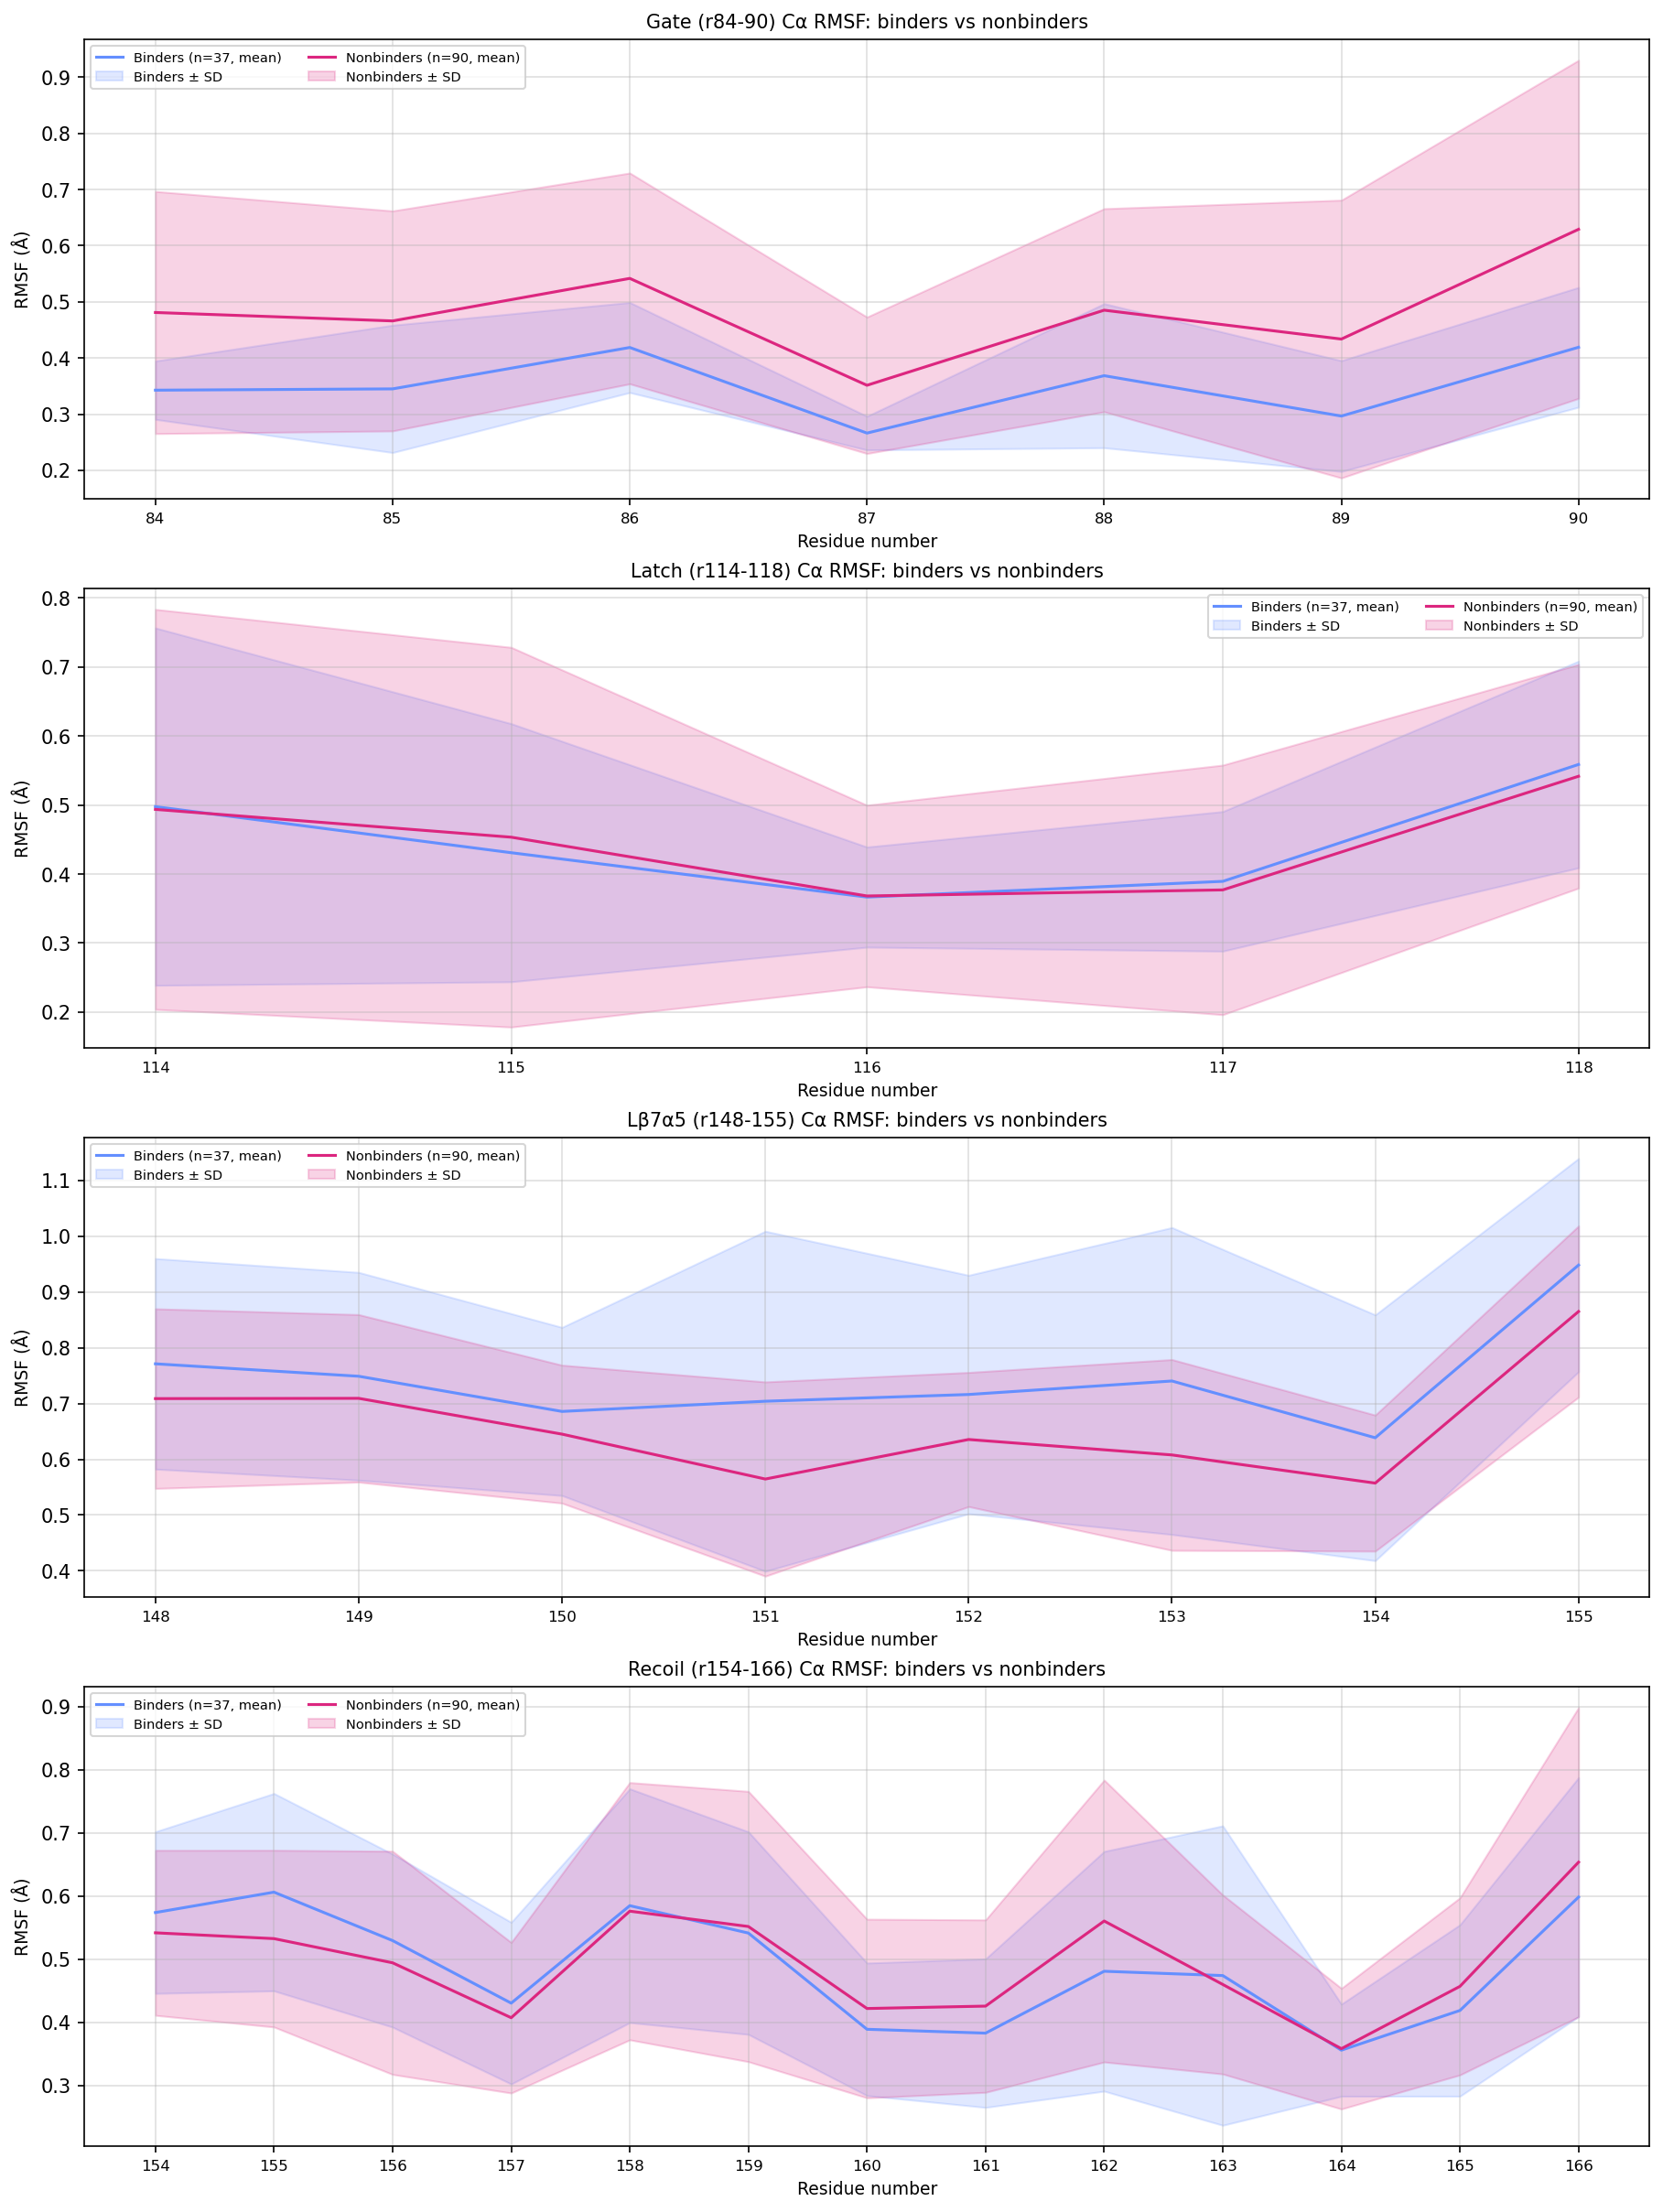

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Plot per-residue Cα RMSF for structural regions
# Combines legacy seqID and new pair_XXXX naming conventions
# Binders (blue):    legacy binders + pair binders
# Nonbinders (red):  legacy nb + pair nb + low_pkt + fail_gate
# ------------------------------------------------------------
base   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
runrel = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"

TYPE_SUBDIR = {
    "binder":    "binders",
    "nb":        "nonbinders",
    "low_pkt":   "neg_low_pkt",
    "fail_gate": "neg_fail_gate",
}

# Legacy seqID-style
legacy_binder_ids = ["seq16", "seq14", "seq10", "seq17", "seq39", "seq42"]
legacy_nb_ids     = ["seq1",  "seq2",  "seq3",  "seq4",  "seq5",  "seq6",  "seq7"]

# New pair_XXXX-style
pair_binder_ids      = ["3069", "3070", "3074", "3092", "3098", 
                        "3059", "3062", "3063", "3066", "3067", 
                        "3068", "3071", "3072", "3073", "3075",
                        "3076", "3077", "3078", "3079", "3080", 
                        "3085", "3086", "3087", "3088", "3091", 
                        "3099", "3100", "3101", "3103", "3104", "3108"]
pair_nb_ids          = ["0052", "0091", "0246", "0269", "0272",
                        "0276", "0288", "0351", "0502", "0506",
                        "0647", "0777", "0827", "1824", "1939",
                        "0822", "0865", "0867", "1860", 
                        "1965",
                        "0341", "0450", "0549", "0567", "0584",
                        "0602", "0684", "0736", "0748", "0765",
                        "0811", "0868", "0876", "0878", "0883",
                        "0891", "0908", "0932", "0940", "0974", 
                        "0977", "1011", "1023", "1102", "1313", 
                        "1397", "1654", "1656", "1658", "1671",
                        "1679", "1709", "1710", "1737", "1758",
                        "1784", "1785", "1792", "1835", "1847",
                        "1914", "1922", "1938", "1961"]
pair_low_pkt_ids     = ["0008", "0393", "0482", "1331", "1931",
                        "0065", "0947", "0948", "1413"]
pair_fail_gate_ids   = ["0715", "1094", "1682", "1739", "1941",
                        "0014", "0263", "0540", "0997", "1745"]

# Each entry: (folder_name, seq_type)
binder_list = (
    [(f"{sid}_binder",     "binder")    for sid in legacy_binder_ids]   +
    [(f"pair_{i}_binder",  "binder")    for i   in pair_binder_ids]
)

nonbinder_list = (
    [(f"{sid}_nb",           "nb")        for sid in legacy_nb_ids]       +
    [(f"pair_{i}_nb",        "nb")        for i   in pair_nb_ids]          +
    [(f"pair_{i}_low_pkt",   "low_pkt")   for i   in pair_low_pkt_ids]    +
    [(f"pair_{i}_fail_gate", "fail_gate") for i   in pair_fail_gate_ids]
)

REGIONS = {
    "Gate (r84-90)":      "rmsf_PL_ca_gate.xvg",
    "Latch (r114-118)":   "rmsf_PL_ca_latch.xvg",
    "Lβ7α5 (r148-155)":  "rmsf_PL_ca_Lb7a5.xvg",
    "Recoil (r154-166)":  "rmsf_PL_ca_recoil.xvg",
}

NM_TO_ANG = 10.0

# -------------------------------------------------------------------
# Load per-residue RMSF for a list of (folder_name, seq_type) tuples
# Returns {residue_id: [rmsf_seq1, rmsf_seq2, ...]} in Å
# -------------------------------------------------------------------
def load_rmsf_group(seq_list, region_fname):
    group = {}
    for folder_name, seq_type in seq_list:
        filepath = os.path.join(base, TYPE_SUBDIR[seq_type], folder_name,
                                runrel, region_fname)
        if not os.path.exists(filepath):
            print(f"WARNING: not found — {filepath}")
            continue
        x_data, y_data = get_data(filepath)
        for resid, rmsf in zip(x_data.astype(int), y_data):
            group.setdefault(resid, []).append(rmsf * NM_TO_ANG)
    return group

# -------------------------------------------------------------------
# Build per-region summary DataFrames and plot
# -------------------------------------------------------------------
n_panels = len(REGIONS)
fig, axes = plt.subplots(nrows=n_panels, ncols=1,
                         figsize=(12, 4 * n_panels), dpi=150,
                         constrained_layout=True)

if n_panels == 1:
    axes = [axes]

for ax, (region_name, region_fname) in zip(axes, REGIONS.items()):

    binder_data    = load_rmsf_group(binder_list,    region_fname)
    nonbinder_data = load_rmsf_group(nonbinder_list, region_fname)

    common_residues = sorted(set(binder_data.keys()) & set(nonbinder_data.keys()))

    rows = []
    for resid in common_residues:
        b_vals  = binder_data[resid]
        nb_vals = nonbinder_data[resid]

        b_mean  = np.mean(b_vals)
        b_sd    = np.std(b_vals,  ddof=1) if len(b_vals)  > 1 else 0.0
        nb_mean = np.mean(nb_vals)
        nb_sd   = np.std(nb_vals, ddof=1) if len(nb_vals) > 1 else 0.0
        pct_diff = (b_mean - nb_mean) / nb_mean * 100 if nb_mean != 0 else np.nan

        rows.append({
            "Residue":            resid,
            "Binder mean (A)":    round(b_mean,           4),
            "Binder SD (A)":      round(b_sd,             4),
            "Nonbinder mean (A)": round(nb_mean,           4),
            "Nonbinder SD (A)":   round(nb_sd,             4),
            "Diff (B - NB, A)":   round(b_mean - nb_mean,  4),
            "% diff (vs NB)":     round(pct_diff,           2),
        })

    df = pd.DataFrame(rows).set_index("Residue")
    print(f"\n{'='*60}")
    print(f"  {region_name}  |  "
          f"Binders: n={len(binder_list)}  Nonbinders: n={len(nonbinder_list)}")
    print(f"{'='*60}")
    print(df.to_string())

    residues = np.array(common_residues)
    b_means  = df["Binder mean (A)"].values
    b_sds    = df["Binder SD (A)"].values
    nb_means = df["Nonbinder mean (A)"].values
    nb_sds   = df["Nonbinder SD (A)"].values

    ax.plot(residues, b_means,  color="#648FFF", lw=1.5,
            label=f"Binders (n={len(binder_list)}, mean)")
    ax.fill_between(residues, b_means - b_sds, b_means + b_sds,
                    color="#648FFF", alpha=0.2, label="Binders ± SD")

    ax.plot(residues, nb_means, color="#DC267F", lw=1.5,
            label=f"Nonbinders (n={len(nonbinder_list)}, mean)")
    ax.fill_between(residues, nb_means - nb_sds, nb_means + nb_sds,
                    color="#DC267F", alpha=0.2, label="Nonbinders ± SD")

    ax.set_title(f"{region_name} Cα RMSF: binders vs nonbinders", fontsize=10)
    ax.set_xlabel("Residue number", fontsize=9)
    ax.set_ylabel("RMSF (Å)", fontsize=9)
    ax.set_xticks(residues)
    ax.set_xticklabels(residues, fontsize=8)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.4)

plt.show()

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
# fig.savefig(os.path.join(base, "analysis", "rmsf_ca_regions_binders_vs_nonbinders.png"),dpi=300, bbox_inches="tight")

              Group  Gate mean (A)  Gate SD (A)  Latch mean (A)  Latch SD (A)  Lβ7α5 mean (A)  Lβ7α5 SD (A)  Recoil mean (A)  Recoil SD (A)
Sequence                                                                                                                                   
seq16        Binder         0.3103       0.0525          0.3432        0.0621          0.6839        0.0759           0.4310         0.1315
seq14        Binder         0.2811       0.0542          0.2676        0.0383          0.3398        0.0543           0.3379         0.0544
seq10        Binder         0.2861       0.0551          0.3174        0.0536          0.4932        0.1055           0.5536         0.1234
seq17        Binder         0.2911       0.0486          0.3216        0.0640          0.9550        0.2523           0.4226         0.1445
seq39        Binder         0.3661       0.0572          0.5592        0.1597          0.6838        0.1321           0.6095         0.1367
seq42        Binder 

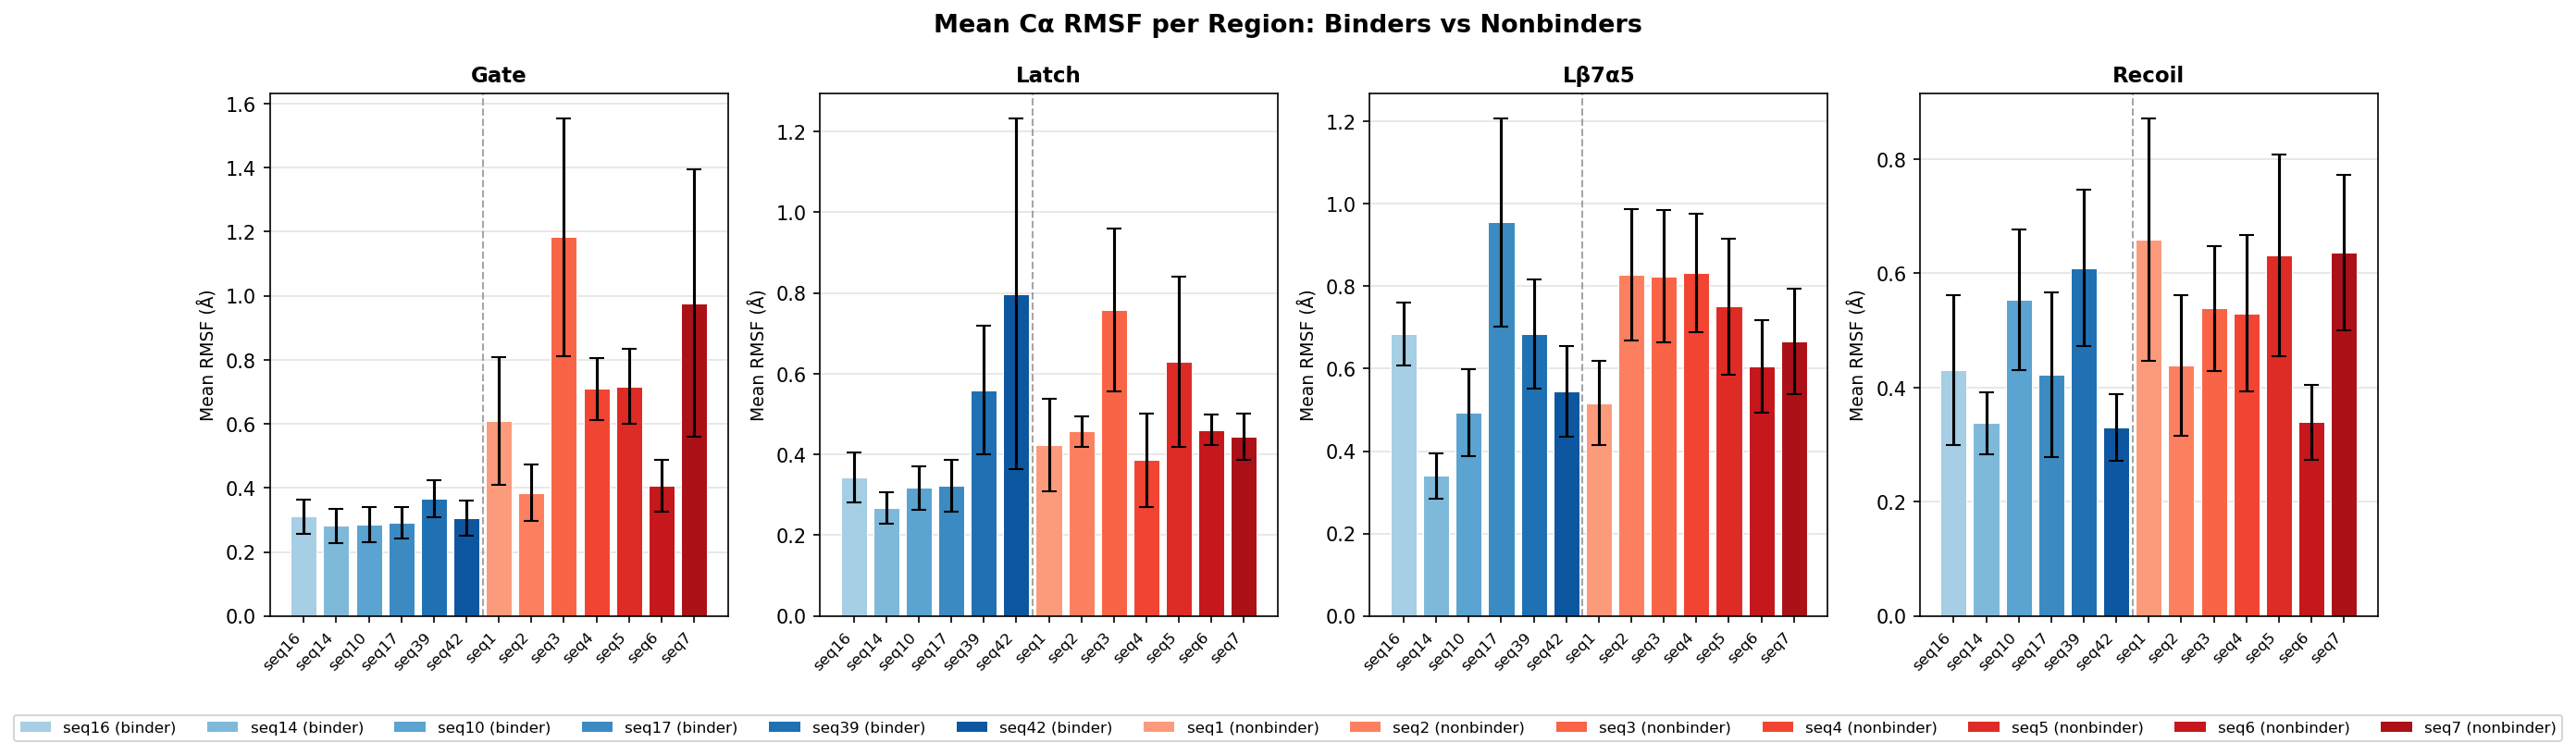

In [23]:
# ------------------------------------------------------------
# Cα RMSF per-sequence summary table + region comparison plot
# Rows = sequences, Columns = mean & SD for each region
# ------------------------------------------------------------
base   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
runrel = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"

binder_seqs    = [("seq16", "binders", "binder"), ("seq14", "binders", "binder"),
                  ("seq10", "binders", "binder"), ("seq17", "binders", "binder"),
                  ("seq39", "binders", "binder"), ("seq42", "binders", "binder")]

nonbinder_seqs = [("seq1",  "nonbinders", "nb"), ("seq2",  "nonbinders", "nb"),
                  ("seq3",  "nonbinders", "nb"), ("seq4",  "nonbinders", "nb"),
                  ("seq5",  "nonbinders", "nb"), ("seq6",  "nonbinders", "nb"),
                  ("seq7",  "nonbinders", "nb")]

REGIONS = {
    "Gate":   "rmsf_PL_ca_gate.xvg",
    "Latch":  "rmsf_PL_ca_latch.xvg",
    "Lβ7α5":  "rmsf_PL_ca_Lb7a5.xvg",
    "Recoil": "rmsf_PL_ca_recoil.xvg",
}

NM_TO_ANG = 10.0

def load_rmsf_single(seq, seq_type, suffix, region_fname):
    filepath = os.path.join(base, seq_type, f"{seq}_{suffix}", runrel, region_fname)
    if not os.path.exists(filepath):
        print(f"WARNING: not found — {filepath}")
        return []
    values = []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            parts = line.split()
            if len(parts) == 2:
                try:
                    values.append(float(parts[1]) * NM_TO_ANG)
                except ValueError:
                    continue
    return values

# -------------------------------------------------------------------
# Build one row per sequence, with mean & SD columns for each region
# -------------------------------------------------------------------
all_seqs = (
    [(seq, seq_type, suffix, "Binder")    for seq, seq_type, suffix in binder_seqs] +
    [(seq, seq_type, suffix, "Nonbinder") for seq, seq_type, suffix in nonbinder_seqs]
)

rows = []
for seq, seq_type, suffix, group in all_seqs:
    row = {"Sequence": seq, "Group": group}
    for region_name, region_fname in REGIONS.items():
        vals = load_rmsf_single(seq, seq_type, suffix, region_fname)
        row[f"{region_name} mean (A)"] = round(np.mean(vals), 4) if vals else np.nan
        row[f"{region_name} SD (A)"]   = round(np.std(vals, ddof=1), 4) if len(vals) > 1 else np.nan
    rows.append(row)

df = pd.DataFrame(rows).set_index("Sequence")

print(df.to_string())

# -------------------------------------------------------------------
# Assign shades of blue (binders) and red (nonbinders)
# -------------------------------------------------------------------
n_binders    = len(binder_seqs)
n_nonbinders = len(nonbinder_seqs)

# Sample from middle of colormap to avoid too-light or too-dark extremes
binder_colors    = [cm.Blues(v)   for v in np.linspace(0.35, 0.85, n_binders)]
nonbinder_colors = [cm.Reds(v)    for v in np.linspace(0.35, 0.85, n_nonbinders)]

seq_colors = {}
for i, (seq, *_) in enumerate(binder_seqs):
    seq_colors[seq] = binder_colors[i]
for i, (seq, *_) in enumerate(nonbinder_seqs):
    seq_colors[seq] = nonbinder_colors[i]

# -------------------------------------------------------------------
# Plot: one subplot per region, grouped bars per sequence with error bars
# -------------------------------------------------------------------
region_names = list(REGIONS.keys())
fig, axes = plt.subplots(1, len(region_names), figsize=(16, 5), dpi=150, sharey=False)

for ax, region_name in zip(axes, region_names):
    seqs   = df.index.tolist()
    means  = df[f"{region_name} mean (A)"].values
    sds    = df[f"{region_name} SD (A)"].values
    colors = [seq_colors[s] for s in seqs]
    x      = np.arange(len(seqs))

    bars = ax.bar(x, means, yerr=sds, color=colors, capsize=4,
                  edgecolor="white", linewidth=0.5)

    # Dashed vertical separator between binders and nonbinders
    ax.axvline(n_binders - 0.5, color="gray", linewidth=1.0,
               linestyle="--", alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(seqs, rotation=45, ha="right", fontsize=8)
    ax.set_title(region_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("Mean RMSF (Å)", fontsize=9)
    ax.grid(True, axis="y", alpha=0.35)
    ax.set_axisbelow(True)

# -------------------------------------------------------------------
# Shared legend: one entry per sequence
# -------------------------------------------------------------------
from matplotlib.patches import Patch
legend_handles = (
    [Patch(facecolor=seq_colors[s], label=f"{s} (binder)")    for s, *_ in binder_seqs] +
    [Patch(facecolor=seq_colors[s], label=f"{s} (nonbinder)") for s, *_ in nonbinder_seqs]
)
fig.legend(handles=legend_handles, loc="lower center",
           ncol=n_binders + n_nonbinders, fontsize=8,
           bbox_to_anchor=(0.5, -0.08), frameon=True)

fig.suptitle("Mean Cα RMSF per Region: Binders vs Nonbinders", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
# fig.savefig(os.path.join(base, "analysis", "rmsf_ca_per_seq_per_region.png"),
#             dpi=300, bbox_inches="tight")
# df.to_csv(os.path.join(base, "analysis", "rmsf_ca_per_seq_summary.csv"))

                              Group  Gate (r84-90) mean (A)  Gate (r84-90) SD (A)  Latch (r114-118) mean (A)  Latch (r114-118) SD (A)  Lβ7α5 (r148-155) mean (A)  Lβ7α5 (r148-155) SD (A)  C-term α-helix (r154-166) mean (A)  C-term α-helix (r154-166) SD (A)
Sequence                                                                                                                                                                                                                                                       
seq16                        Binder                  0.3103                0.0525                     0.3432                   0.0621                     0.6839                   0.0759                              0.4310                            0.1315
seq14                        Binder                  0.2811                0.0542                     0.2676                   0.0383                     0.3398                   0.0543                              0.3379           

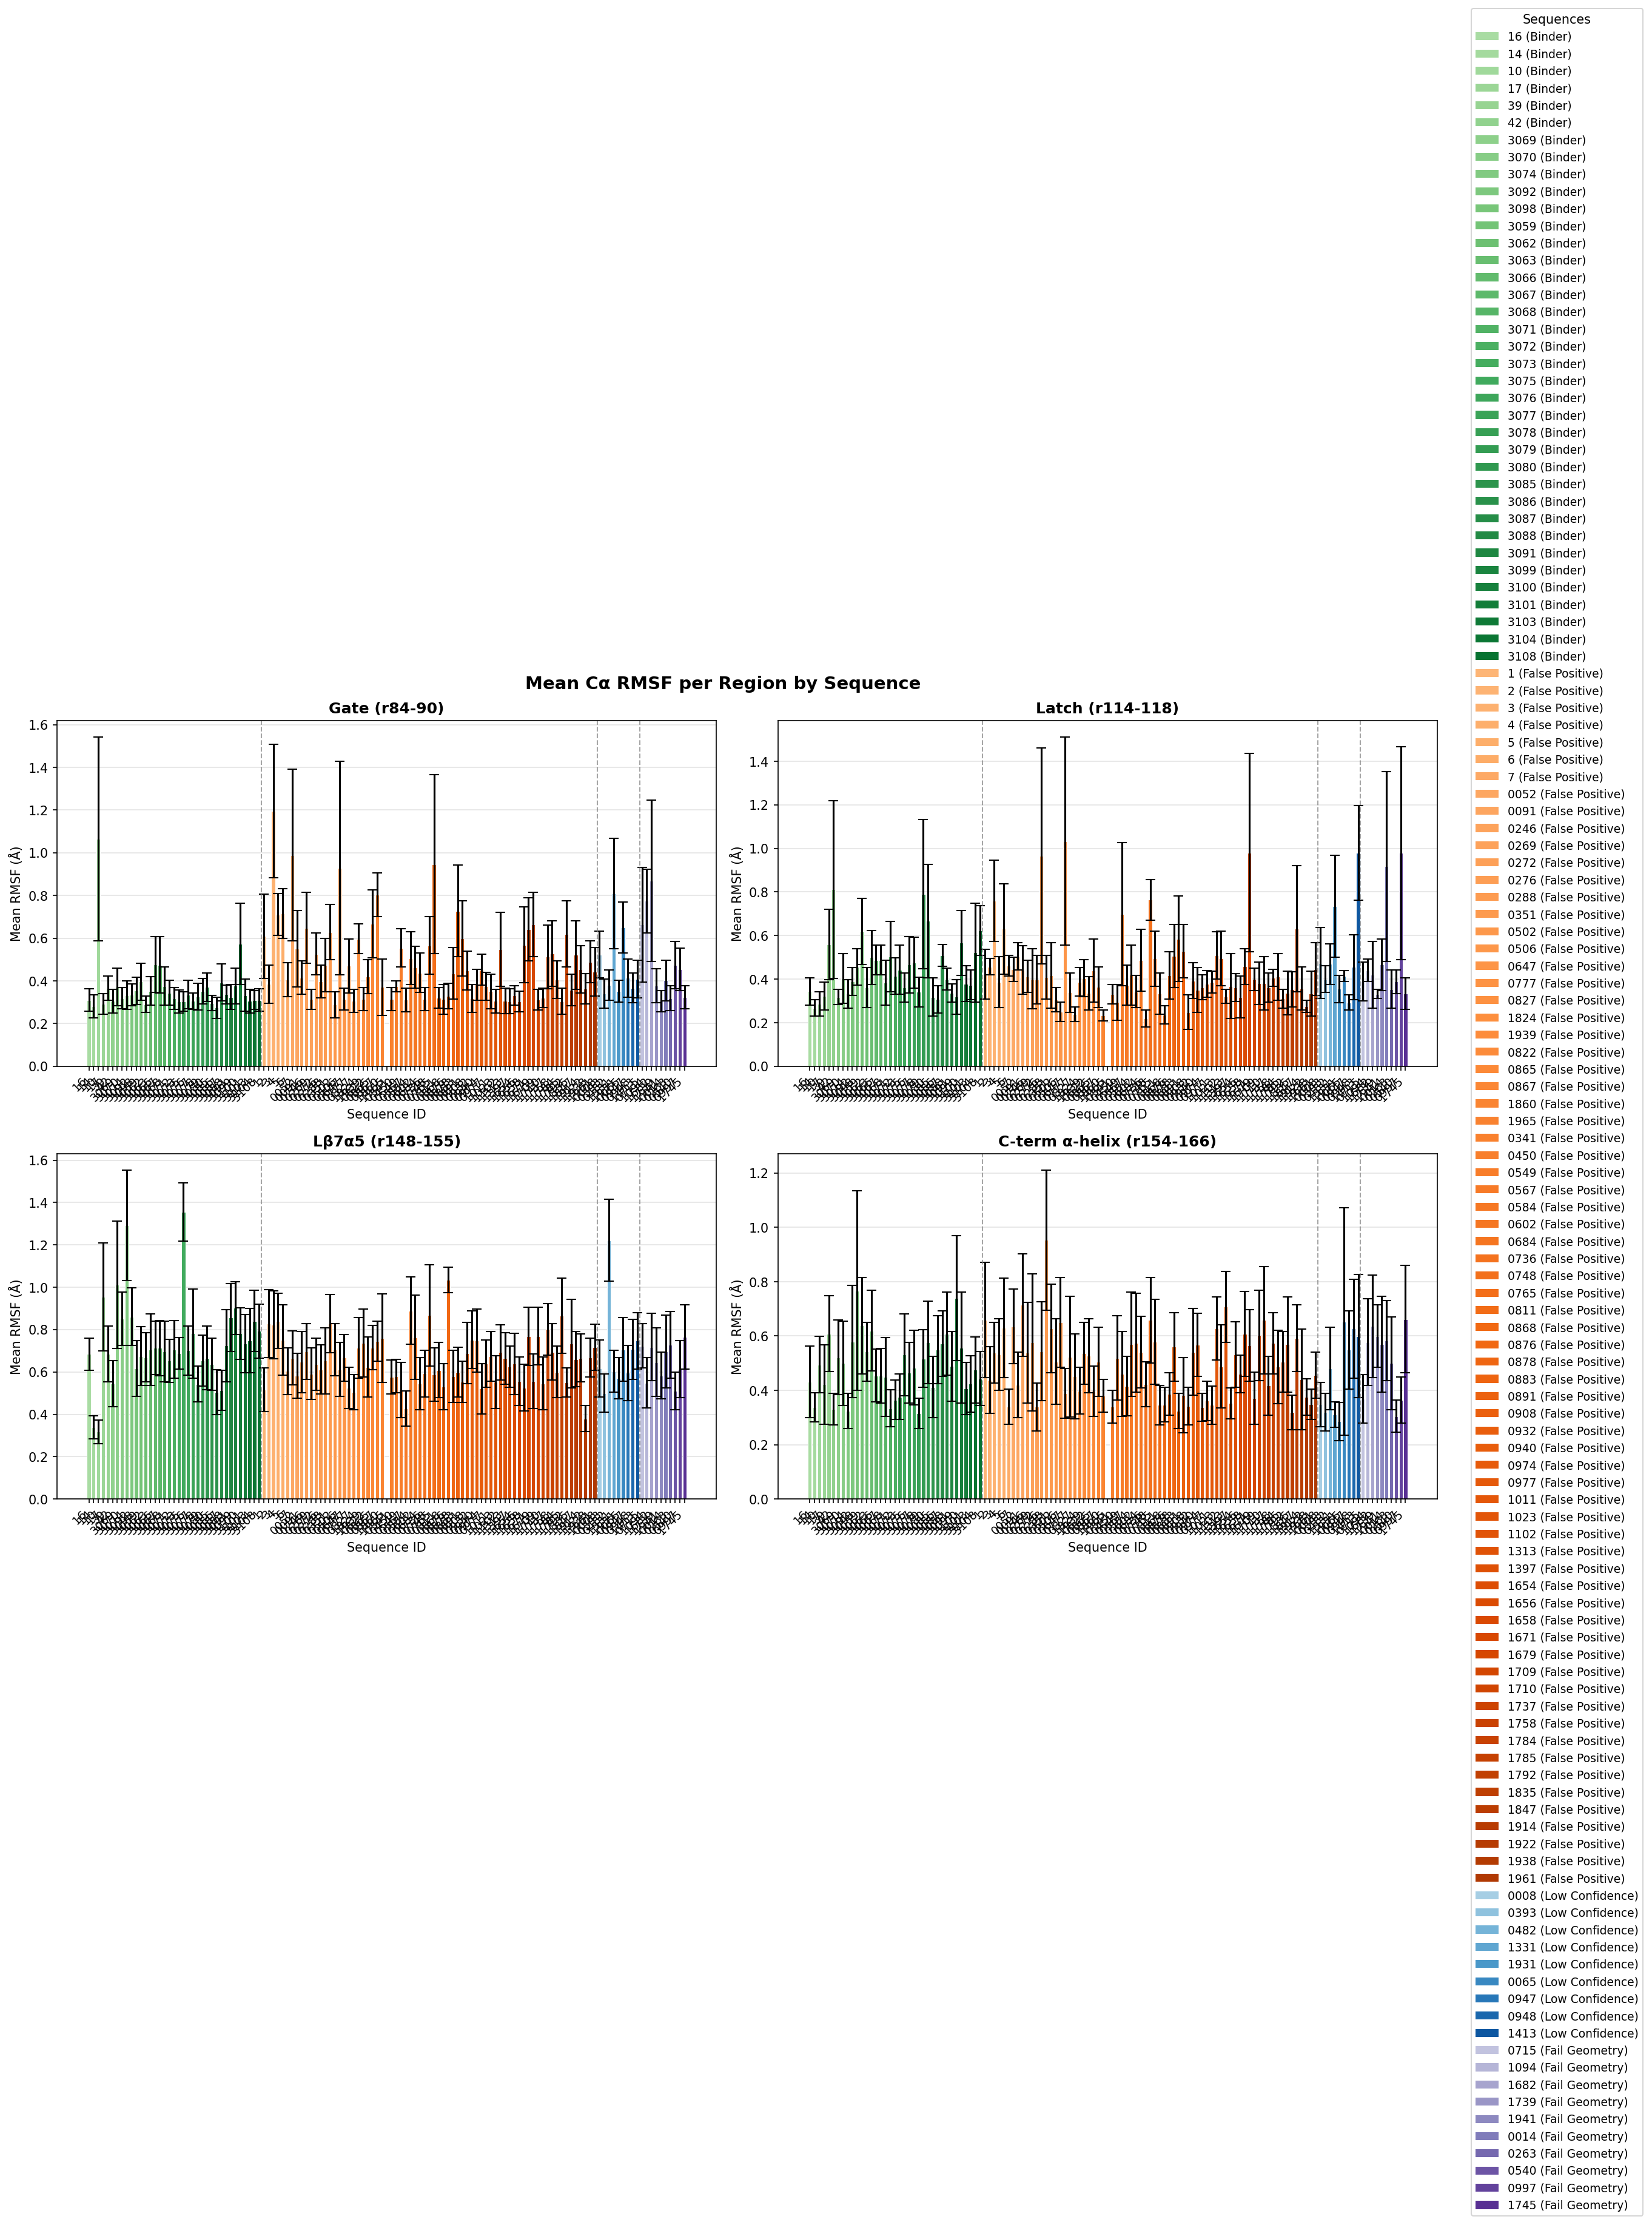

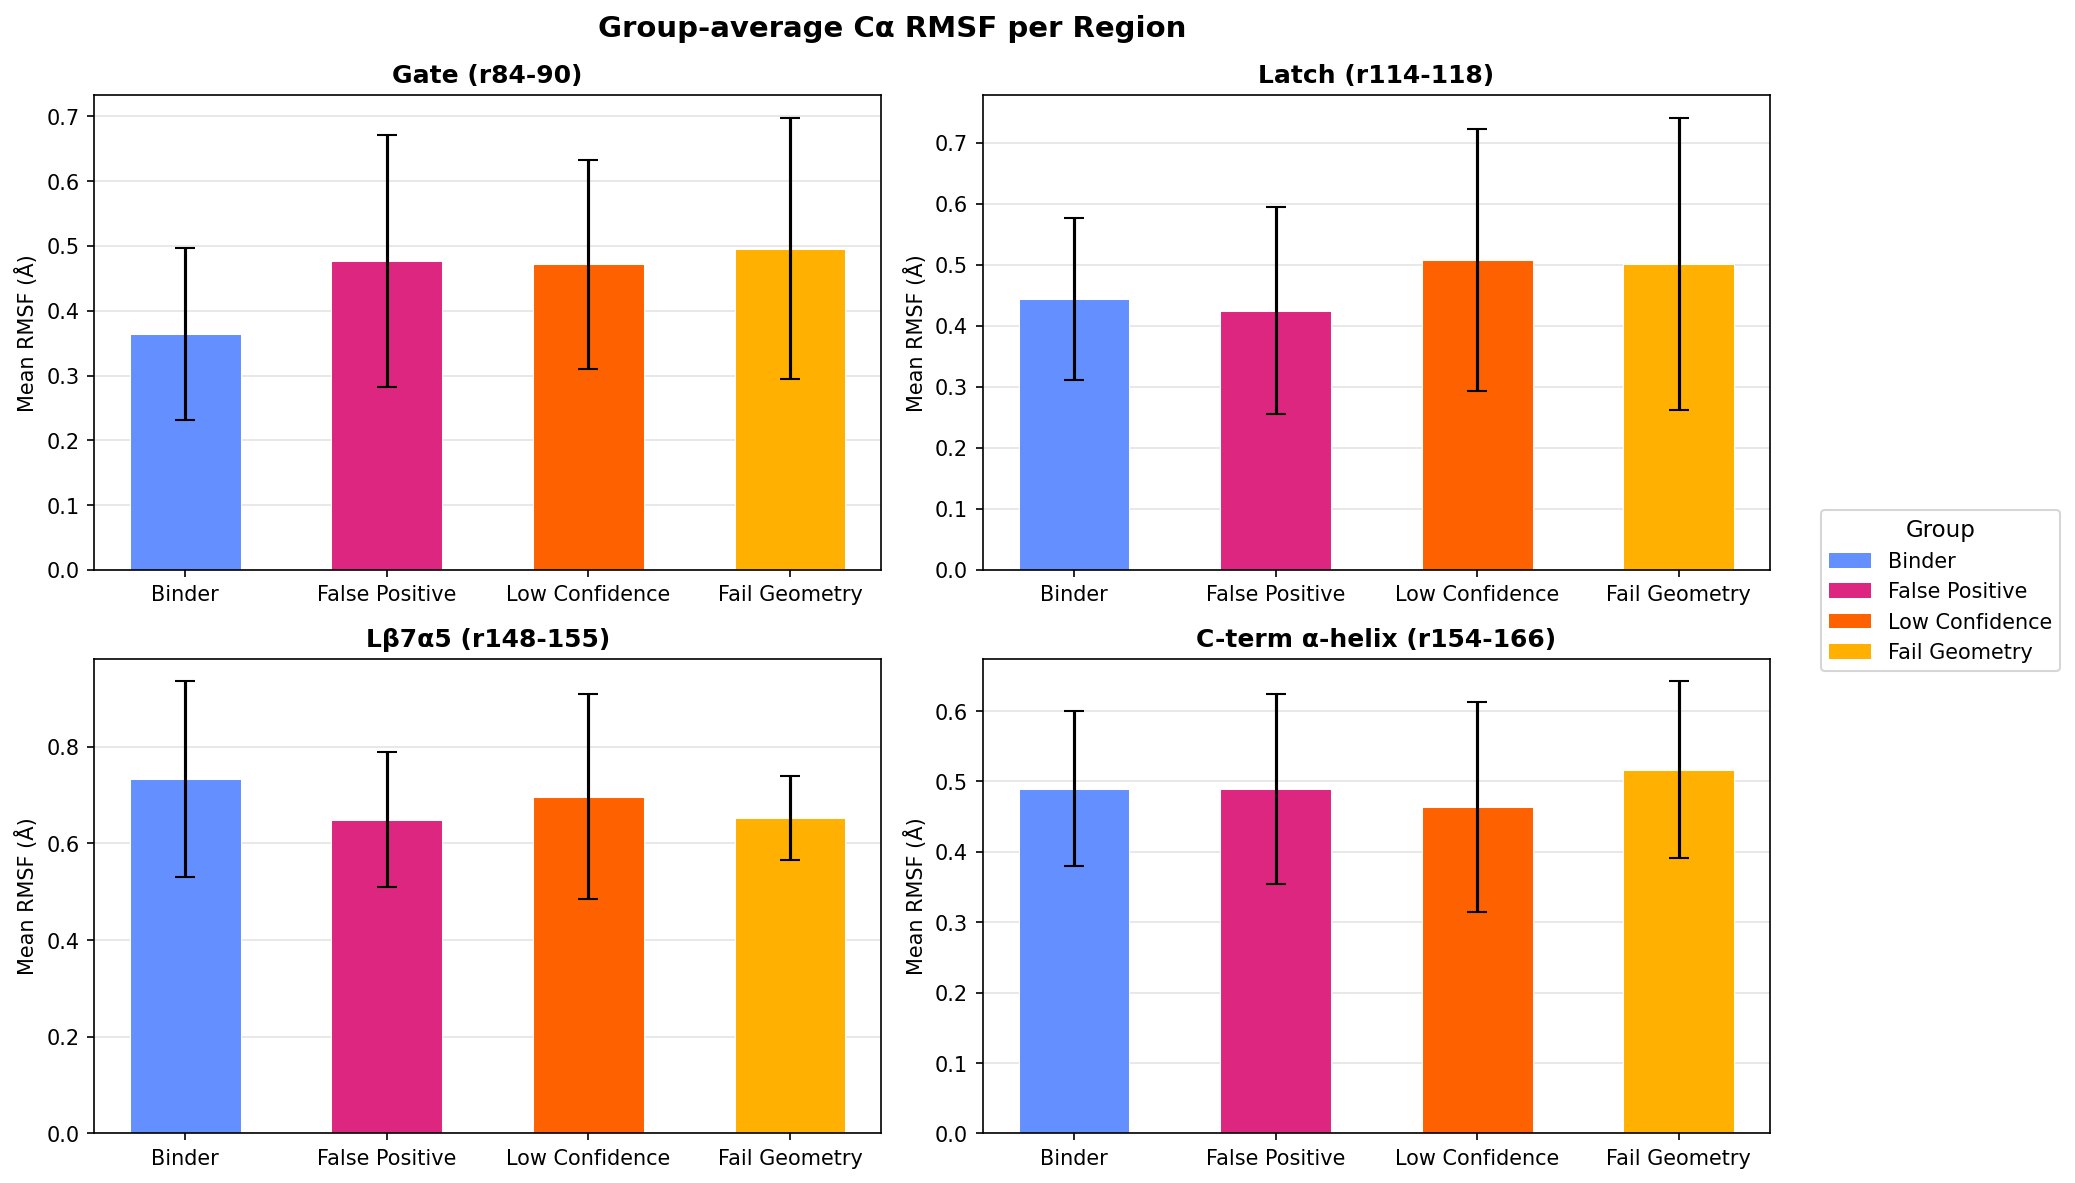

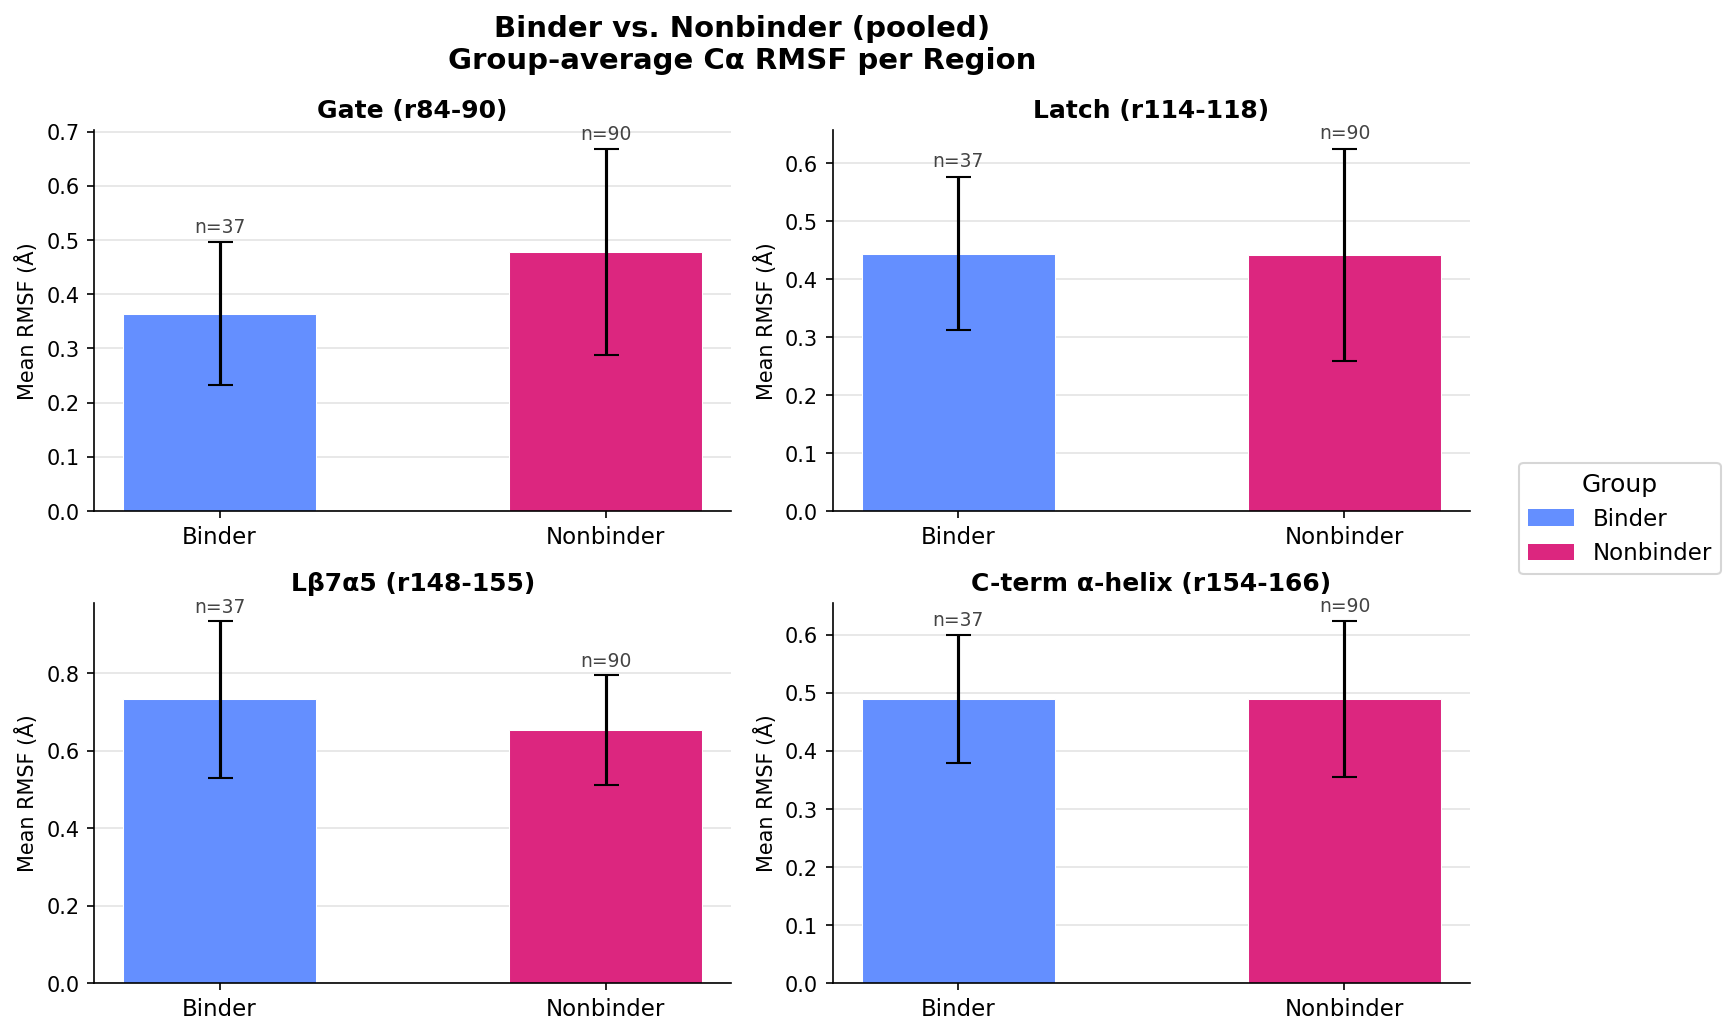

In [ ]:
# ------------------------------------------------------------
# Cα RMSF per-sequence summary table + region comparison plot
# Bar order: all binders | all nonbinders | low_pkt | fail_gate
# ------------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch

base   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
runrel = "prod_md_0p9_cutoff_3dt_64x1_16PME_642dd"

TYPE_SUBDIR = {
    "binder":    "binders",
    "nb":        "nonbinders",
    "low_pkt":   "neg_low_pkt",
    "fail_gate": "neg_fail_gate",
}

TYPE_GROUP = {
    "binder":    "Binder",
    "nb":        "False Positive",
    "low_pkt":   "Low Confidence",
    "fail_gate": "Fail Geometry",
}

GROUP_CMAP = {
    "Binder":          cm.Greens,
    "False Positive":  cm.Oranges,
    "Low Confidence":  cm.Blues,
    "Fail Geometry":   cm.Purples,
}

GROUP_COLOR = {
    'Binder':         '#648FFF',   # blue
    'False Positive': '#DC267F',   # magenta
    'Low Confidence': '#FE6100',   # orange
    'Fail Geometry':  '#FFB000',   # gold
}

# Colors for the pooled binder vs nonbinder plot (Figure 3)
POOLED_COLOR = {
    'Binder':    '#648FFF',   # blue  (same as above)
    'Nonbinder': '#DC267F',   # magenta
}

# Legacy seqID-style binders: folder is seqID_binder
legacy_binder_ids    = ["seq16", "seq14", "seq10", "seq17", "seq39", "seq42"]
legacy_nb_ids        = ["seq1",  "seq2",  "seq3",  "seq4",  "seq5",  "seq6",  "seq7"]

# New pair_XXXX-style
pair_binder_ids      = ["3069", "3070", "3074", "3092", "3098",
                        "3059", "3062", "3063", "3066", "3067",
                        "3068", "3071", "3072", "3073", "3075",
                        "3076", "3077", "3078", "3079", "3080",
                        "3085", "3086", "3087", "3088", "3091",
                        "3099", "3100", "3101", "3103", "3104", "3108"]
pair_nb_ids          = ["0052", "0091", "0246", "0269", "0272",
                        "0276", "0288", "0351", "0502", "0506",
                        "0647", "0777", "0827", "1824", "1939",
                        "0822", "0865", "0867", "1860", 
                        "1965",
                        "0341", "0450", "0549", "0567", "0584",
                        "0602", "0684", "0736", "0748", "0765",
                        "0811", "0868", "0876", "0878", "0883",
                        "0891", "0908", "0932", "0940", "0974", 
                        "0977", "1011", "1023", "1102", "1313", 
                        "1397", "1654", "1656", "1658", "1671",
                        "1679", "1709", "1710", "1737", "1758",
                        "1784", "1785", "1792", "1835", "1847",
                        "1914", "1922", "1938", "1961"]
pair_low_pkt_ids     = ["0008", "0393", "0482", "1331", "1931",
                        "0065", "0947", "0948", "1413"]
pair_fail_gate_ids   = ["0715", "1094", "1682", "1739", "1941",
                        "0014", "0263", "0540", "0997", "1745"]

# Each entry: (display_name, folder_name, type)
all_sequences = (
    [(sid,                   f"{sid}_binder",      "binder")    for sid in legacy_binder_ids]    +
    [(f"pair_{i}_binder",    f"pair_{i}_binder",   "binder")    for i   in pair_binder_ids]      +
    [(sid,                   f"{sid}_nb",           "nb")        for sid in legacy_nb_ids]        +
    [(f"pair_{i}_nb",        f"pair_{i}_nb",        "nb")        for i   in pair_nb_ids]          +
    [(f"pair_{i}_low_pkt",   f"pair_{i}_low_pkt",   "low_pkt")  for i   in pair_low_pkt_ids]     +
    [(f"pair_{i}_fail_gate", f"pair_{i}_fail_gate", "fail_gate") for i   in pair_fail_gate_ids]
)

REGIONS = {
    "Gate (r84-90)":             "rmsf_PL_ca_gate.xvg",
    "Latch (r114-118)":          "rmsf_PL_ca_latch.xvg",
    "Lβ7α5 (r148-155)":         "rmsf_PL_ca_Lb7a5.xvg",
    "C-term α-helix (r154-166)": "rmsf_PL_ca_recoil.xvg",
}

NM_TO_ANG = 10.0

# -------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------
def truncate_label(display_name):
    parts = display_name.split("_")
    if parts[0] == "pair" and len(parts) >= 2:
        return parts[1]          # pair_0001_binder -> 0001
    if display_name.startswith("seq"):
        return display_name[len("seq"):]   # seq16 -> 16
    return display_name

def get_data(filepath):
    """Parse a GROMACS .xvg file, skipping comment/label lines."""
    x_vals, y_vals = [], []
    with open(filepath) as fh:
        for line in fh:
            if line.startswith(('#', '@')):
                continue
            cols = line.split()
            if len(cols) >= 2:
                x_vals.append(float(cols[0]))
                y_vals.append(float(cols[1]))
    return np.array(x_vals), np.array(y_vals)

def load_rmsf_single(folder_name, seq_type, region_fname):
    filepath = os.path.join(base, TYPE_SUBDIR[seq_type], folder_name, runrel, region_fname)
    if not os.path.exists(filepath):
        print(f"WARNING: not found — {filepath}")
        return []
    _, rmsf = get_data(filepath)
    return (rmsf * NM_TO_ANG).tolist()

# -------------------------------------------------------------------
# Build per-sequence DataFrame
# -------------------------------------------------------------------
rows = []
for display_name, folder_name, seq_type in all_sequences:
    group = TYPE_GROUP[seq_type]
    row = {"Sequence": display_name, "Group": group}
    for region_name, region_fname in REGIONS.items():
        vals = load_rmsf_single(folder_name, seq_type, region_fname)
        row[f"{region_name} mean (A)"] = round(np.mean(vals), 4)        if vals          else np.nan
        row[f"{region_name} SD (A)"]   = round(np.std(vals, ddof=1), 4) if len(vals) > 1 else np.nan
    rows.append(row)

df = pd.DataFrame(rows).set_index("Sequence")
print(df.to_string())

# -------------------------------------------------------------------
# Per-sequence colors
# -------------------------------------------------------------------
seq_colors = {}
group_seqs = {}
for display_name, _, seq_type in all_sequences:
    group = TYPE_GROUP[seq_type]
    group_seqs.setdefault(group, []).append(display_name)

for group, seqs in group_seqs.items():
    cmap   = GROUP_CMAP[group]
    shades = [cmap(v) for v in np.linspace(0.35, 0.85, max(len(seqs), 1))]
    for display_name, color in zip(seqs, shades):
        seq_colors[display_name] = color

group_sizes   = [len(v) for v in group_seqs.values()]
group_offsets = np.cumsum([0] + group_sizes[:-1])

region_names = list(REGIONS.keys())

# -------------------------------------------------------------------
# Figure 1: per-sequence bars, 2×2 grid
# -------------------------------------------------------------------
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 10), dpi=150, sharey=False)
axes1 = axes1.flatten()

for ax, region_name in zip(axes1, region_names):
    seqs        = df.index.tolist()
    tick_labels = [truncate_label(s) for s in seqs]
    means       = df[f"{region_name} mean (A)"].values
    sds         = df[f"{region_name} SD (A)"].values
    colors      = [seq_colors[s] for s in seqs]
    x           = np.arange(len(seqs))

    ax.bar(x, means, yerr=sds, color=colors, capsize=4,
           edgecolor="white", linewidth=0.5)

    for offset in group_offsets[1:]:
        ax.axvline(offset - 0.5, color="gray", linewidth=1.0,
                   linestyle="--", alpha=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=9)
    ax.set_title(region_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Sequence ID", fontsize=10)
    ax.set_ylabel("Mean RMSF (Å)", fontsize=10)
    ax.grid(True, axis="y", alpha=0.35)
    ax.set_axisbelow(True)

legend_handles1 = [
    Patch(facecolor=seq_colors[dn], label=f"{truncate_label(dn)} ({TYPE_GROUP[st]})")
    for dn, _, st in all_sequences
]
fig1.legend(handles=legend_handles1,
            loc="center left", bbox_to_anchor=(1.01, 0.5),
            ncol=1, fontsize=9, frameon=True,
            title="Sequences", title_fontsize=10)

fig1.suptitle("Mean Cα RMSF per Region by Sequence", fontsize=14, fontweight="bold")
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 2: group-average bars, 2×2 grid (4 groups)
# -------------------------------------------------------------------
group_order = ["Binder", "False Positive", "Low Confidence", "Fail Geometry"]

group_summary = {}
for group in group_order:
    group_summary[group] = {}
    seqs_in_group = group_seqs.get(group, [])
    for region_name in region_names:
        col  = f"{region_name} mean (A)"
        vals = df.loc[df.index.isin(seqs_in_group), col].dropna().values
        group_summary[group][region_name] = {
            "mean": np.mean(vals)        if len(vals) > 0 else np.nan,
            "sd":   np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
        }

fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8), dpi=150, sharey=False)
axes2 = axes2.flatten()

x2      = np.arange(len(group_order))
colors2 = [GROUP_COLOR[g] for g in group_order]

for ax, region_name in zip(axes2, region_names):
    means2 = [group_summary[g][region_name]["mean"] for g in group_order]
    sds2   = [group_summary[g][region_name]["sd"]   for g in group_order]

    ax.bar(x2, means2, yerr=sds2, color=colors2, capsize=5,
           edgecolor="white", linewidth=0.5, width=0.55)
    ax.set_xticks(x2)
    ax.set_xticklabels(group_order, fontsize=10)
    ax.set_title(region_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean RMSF (Å)", fontsize=10)
    ax.grid(True, axis="y", alpha=0.35)
    ax.set_axisbelow(True)

legend_handles2 = [Patch(facecolor=GROUP_COLOR[g], label=g) for g in group_order]
fig2.legend(handles=legend_handles2,
            loc="center left", bbox_to_anchor=(1.01, 0.5),
            ncol=1, fontsize=10, frameon=True,
            title="Group", title_fontsize=11)

fig2.suptitle("Group-average Cα RMSF per Region", fontsize=14, fontweight="bold")
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 3: pooled Binder vs. Nonbinder, 2×2 grid
# All non-binder subtypes (False Positive, Low Confidence, Fail Geometry)
# are pooled into a single "Nonbinder" group.
# Error bar = SD across all sequences in that pool.
# -------------------------------------------------------------------
NONBINDER_GROUPS = ["False Positive", "Low Confidence", "Fail Geometry"]
pooled_order = ["Binder", "Nonbinder"]

pooled_seqs = {
    "Binder":    group_seqs.get("Binder", []),
    "Nonbinder": [s for g in NONBINDER_GROUPS for s in group_seqs.get(g, [])],
}

pooled_summary = {}
for pool_label, seqs_in_pool in pooled_seqs.items():
    pooled_summary[pool_label] = {}
    for region_name in region_names:
        col  = f"{region_name} mean (A)"
        vals = df.loc[df.index.isin(seqs_in_pool), col].dropna().values
        pooled_summary[pool_label][region_name] = {
            "mean": np.mean(vals)        if len(vals) > 0 else np.nan,
            "sd":   np.std(vals, ddof=1) if len(vals) > 1 else np.nan,
            "n":    len(vals),
        }

fig3, axes3 = plt.subplots(2, 2, figsize=(10, 7), dpi=150, sharey=False)
axes3 = axes3.flatten()

x3      = np.arange(len(pooled_order))
colors3 = [POOLED_COLOR[g] for g in pooled_order]

for ax, region_name in zip(axes3, region_names):
    means3 = [pooled_summary[g][region_name]["mean"] for g in pooled_order]
    sds3   = [pooled_summary[g][region_name]["sd"]   for g in pooled_order]
    ns     = [pooled_summary[g][region_name]["n"]    for g in pooled_order]

    bars = ax.bar(x3, means3, yerr=sds3, color=colors3, capsize=6,
                  edgecolor="white", linewidth=0.5, width=0.5)

    # Annotate n per bar
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (sds3[list(bars).index(bar)] or 0) + 0.01,
                f"n={n}", ha="center", va="bottom", fontsize=9, color="#444444")

    ax.set_xticks(x3)
    ax.set_xticklabels(pooled_order, fontsize=11)
    ax.set_title(region_name, fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean RMSF (Å)", fontsize=10)
    ax.grid(True, axis="y", alpha=0.35)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles3 = [Patch(facecolor=POOLED_COLOR[g], label=g) for g in pooled_order]
fig3.legend(handles=legend_handles3,
            loc="center left", bbox_to_anchor=(1.01, 0.5),
            ncol=1, fontsize=11, frameon=True,
            title="Group", title_fontsize=12)

fig3.suptitle(
    "Binder vs. Nonbinder (pooled)\nGroup-average Cα RMSF per Region",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()

plt.show()

# -------------------------------------------------------------------
# Save outputs
# -------------------------------------------------------------------
# fig1.savefig(os.path.join(base, "analysis", "rmsf_ca_per_seq_per_region.png"), dpi=300, bbox_inches="tight")
# fig2.savefig(os.path.join(base, "analysis", "rmsf_ca_group_avg_per_region.png"), dpi=300, bbox_inches="tight")
# fig3.savefig(os.path.join(base, "analysis", "rmsf_ca_binder_vs_nonbinder_pooled.png"), dpi=300, bbox_inches="tight")
# df.to_csv(os.path.join(base, "analysis", "rmsf_ca_per_seq_summary.csv"))